# 1. Lesion
Generate lesion mask by fsleyes in individual space
-> Block the T1_Brain and T2_Brain img
-> Registration with or sithou mask

In [21]:
# Block the T1_Brain and T2_Brain img
import os
import sys
import nibabel as nib
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_pipeline
from tqdm import tqdm
import pandas as pd
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
subid = 'sub-001'
output_dir = os.path.join(pipel_dir, dataset_name, subid)

lesion_mask = nib.load(os.path.join(output_dir,"lesion_mask.nii.gz"))
T1_Brain = nib.load(os.path.join(output_dir,"T1_Brain_pad.nii.gz"))
T2_Brain = nib.load(os.path.join(output_dir,"T2_Brain_pad.nii.gz"))
T1_data = T1_Brain.get_fdata()
T2_data = T2_Brain.get_fdata()
lesion_data = lesion_mask.get_fdata()

T1_data[lesion_data == 1] = 0
T2_data[lesion_data == 1] = 0

T1_Brain_new = nib.Nifti1Image(T1_data, affine=T1_Brain.affine, header=T1_Brain.header)
T2_Brain_new = nib.Nifti1Image(T2_data, affine=T2_Brain.affine, header=T2_Brain.header)

nib.save(T1_Brain_new, os.path.join(output_dir, "T1_Brain_pad_lesion.nii.gz"))
nib.save(T2_Brain_new, os.path.join(output_dir, "T2_Brain_pad_lesion.nii.gz"))


In [22]:
# Generate the moving mask
T1_data[T1_data > 0] = 1
T1_data[lesion_data == 1] = 0
T1_Brain_mask = nib.Nifti1Image(T1_data, affine=T1_Brain.affine, header=T1_Brain.header)
nib.save(T1_Brain_mask, os.path.join(output_dir, "T1_Brain_pad_lesion_mask.nii.gz"))

T2_data[T2_data > 0] = 1
T2_data[lesion_data == 1] = 0
T2_Brain_mask = nib.Nifti1Image(T2_data, affine=T2_Brain.affine, header=T2_Brain.header)
nib.save(T2_Brain_mask, os.path.join(output_dir, "T2_Brain_pad_lesion_mask.nii.gz"))

In [1]:
# Registration with or without mask
import os
import sys
import nibabel as nib
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_lesion_pipel
from tqdm import tqdm
import pandas as pd
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
subid = 'sub-001'
output_dir = os.path.join(pipel_dir, dataset_name, subid)

tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
tpl_months = ['00','01']
for tpl_month in tpl_months:
    print(f"Running registration → tpl_month={tpl_month}")
    input_files = {
        "T1": f"{output_dir}/T1_Brain_pad_lesion.nii.gz",
        "T2": f"{output_dir}/T2_Brain_pad_lesion.nii.gz"
    }


    multimodal_register_lesion_pipel(
        modalities=["T1", "T2"],
        input_files=input_files,
        tpl_root=tpl_root,
        tpl_month=tpl_month,
        output_dir=output_dir,
        slurm=True
    )

Running registration → tpl_month=00
[INFO] Using default subject moving mask
[INFO] No moving mask used
[INFO] Submitting job: les_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/les_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/les_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 51636437
[INFO] Job ID: 51636437
Running registration → tpl_month=01
[INFO] Using default subject moving mask
[INFO] No moving mask used
[INFO] Submitting job: les_01Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/les_01Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/les_01Mtpl.sh
[INFO] sbatch output: Submitted batch job 51636438
[INFO] Job ID: 51636438


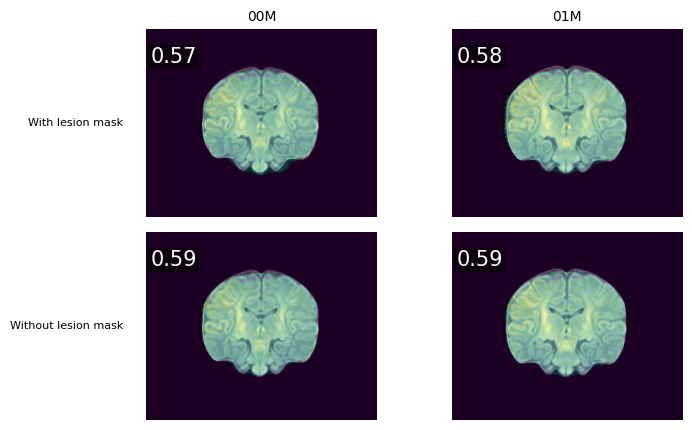

In [7]:
# Show the warped img as the tpl background and calculate the correlation
import os
import sys
import nibabel as nib
import numpy as np
import ants
import matplotlib.pyplot as plt
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_lesion_pipel
from tqdm import tqdm
import pandas as pd
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
subid = 'sub-001'
output_dir = os.path.join(pipel_dir, dataset_name, subid)   
tpl_months = ['00','01']
tpl_dict = {}
msk_dict = {}
for tpl_month in tpl_months:
    tpl_file = os.path.join(
        tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-T1.nii.gz"
    )
    mask_file = os.path.join(
            tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-Mask.nii.gz"
        )
    tpl_dict[tpl_month] = ants.image_read(tpl_file).numpy()
    msk_dict[tpl_month] = ants.image_read(mask_file).numpy()

modality_keys = ['withmovmask', 'withoutmovmask']
n_subj = len(modality_keys)
n_cols = len(tpl_months)
fig, axes = plt.subplots(
    n_subj, n_cols,
    figsize=(4 * n_cols, 2.2 * n_subj),
    squeeze=False
)


for i, modality_key in enumerate(modality_keys):
    for j, tpl_month in enumerate(tpl_months):
        registered_img_path = os.path.join(output_dir,f"T1T2_Brain_pad_lesion_Norm_{modality_key}_to_{tpl_month}Mtpl_Warped.nii.gz")
        img_np = ants.image_read(registered_img_path).numpy()
        tpl_np = tpl_dict[tpl_month]

        ax = axes[i, j]
        ax.axis('off')

        sl = np.argmax(img_np.sum(axis=(0,2)))
        sl = img_np.shape[1] // 2
        ax.imshow(tpl_np[:, sl, :].T, cmap='gray', origin='lower' )
        ax.imshow( img_np[:, sl, :].T,cmap='viridis', alpha=0.4,origin='lower')
        # Calculate R and show in left upper corner
        score = np.corrcoef(tpl_np[msk_dict[tpl_month]>0],img_np[msk_dict[tpl_month]>0])[0, 1]
        ax.text(0.22, 0.80,
                f'{score:.2f}',#{eval_mode}=
                transform=ax.transAxes,
                ha='right',
                va='bottom',
                fontsize=15,
                color='white',
                bbox=dict(
                    facecolor='black',
                    alpha=0.5,
                    edgecolor='none',
                    pad=1.5
                ))
        
        # ---------- column titles ----------
        if i == 0:
            ax.set_title(f'{tpl_month}M', fontsize=10)

    # ---------- row labels ----------
    if modality_key == 'withmovmask':
        modality_label = 'With lesion mask'
    else:
        modality_label = 'Without lesion mask'
    axes[i, 0].text(
        -0.1, 0.5,
        modality_label,
        fontsize=8,
        va='center',
        ha='right',
        transform=axes[i, 0].transAxes
    )

plt.tight_layout()
plt.show()


# 2. T1, T2 or combined

In [1]:
# Registration with or without mask
import os
import sys
import nibabel as nib
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import unimodal_register_pipeline
from tqdm import tqdm
import pandas as pd
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
subid = 'sub-001'
output_dir = os.path.join(pipel_dir, dataset_name, subid)

tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
tpl_months = ['00','01']
for tpl_month in tpl_months:
    print(f"Running registration → tpl_month={tpl_month}")
    input_files = {
        "T1": f"{output_dir}/T1_Brain_pad.nii.gz",
        "T2": f"{output_dir}/T2_Brain_pad.nii.gz"
    }

    unimodal_register_pipeline(
        modalities=["T1", "T2"],
        input_files=input_files,
        tpl_root=tpl_root,
        tpl_month=tpl_month,
        output_dir=output_dir,
        slurm=True
    )

Running registration → tpl_month=00
[INFO] No moving mask used
[INFO] Submitting job: T1o_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/T1o_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/T1o_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 51654850
[INFO] Job ID: 51654850
[INFO] No moving mask used
[INFO] Submitting job: T2o_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/T2o_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/T2o_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 51654851
[INFO] Job ID: 51654851
Running registration → tpl_month=01
[INFO] No moving mask used
[INFO] Submitting job: T1o_01Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/T1o_01Mtpl.sh
[INFO] Command: sbatch /pro

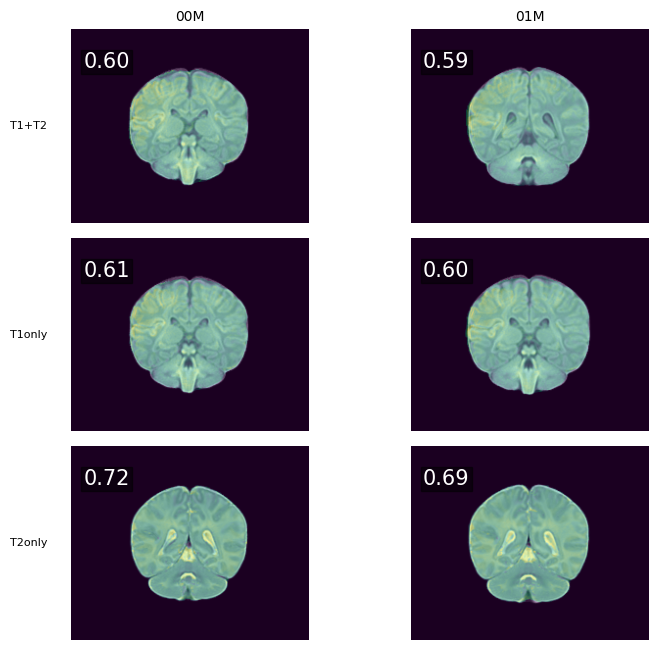

In [6]:
# Show the arped img as the tpl background and calculate the correlation
import os
import sys
import nibabel as nib
import numpy as np
import ants
import matplotlib.pyplot as plt
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_lesion_pipel
from tqdm import tqdm
import pandas as pd
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
subid = 'sub-001'
output_dir = os.path.join(pipel_dir, dataset_name, subid)   
tpl_months = ['00','01']
tpl_dict = {
    'T1': {},
    'T2': {}
}
msk_dict = {}

for tpl_month in tpl_months:

    # ---- T1 ----
    tpl_file = os.path.join(
        tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-T1.nii.gz"
    )
    tpl_dict['T1'][tpl_month] = ants.image_read(tpl_file).numpy()

    # ---- T2 ----
    tpl_file = os.path.join(
        tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-T2.nii.gz"
    )
    tpl_dict['T2'][tpl_month] = ants.image_read(tpl_file).numpy()

    # ---- mask ----
    mask_file = os.path.join(
        tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-Mask.nii.gz"
    )
    msk_dict[tpl_month] = ants.image_read(mask_file).numpy()

template_map = {
    'T1': 'T1',        # multimodal → T1 warped
    'T1only': 'T1',
    'T2only': 'T2'
}

modality_keys = ['T1','T1only', 'T2only']
n_subj = len(modality_keys)
n_cols = len(tpl_months)
fig, axes = plt.subplots(
    n_subj, n_cols,
    figsize=(4 * n_cols, 2.2 * n_subj),
    squeeze=False
)


for i, modality_key in enumerate(modality_keys):

    for j, tpl_month in enumerate(tpl_months):

        registered_img_path = os.path.join(
            output_dir,
            f"{modality_key}_Brain_pad_Norm_to_{tpl_month}Mtpl_Warped.nii.gz"
        )

        if not os.path.exists(registered_img_path):
            axes[i, j].axis('off')
            continue

        img_np = ants.image_read(registered_img_path).numpy()

        # ⭐️关键：选对 template
        tpl_mod = template_map[modality_key]
        tpl_np = tpl_dict[tpl_mod][tpl_month]

        mask = msk_dict[tpl_month] > 0

        ax = axes[i, j]
        ax.axis('off')

        sl = np.argmax(img_np.sum(axis=(0, 2)))

        ax.imshow(tpl_np[:, sl, :].T, cmap='gray', origin='lower')
        ax.imshow(img_np[:, sl, :].T, cmap='viridis', alpha=0.4, origin='lower')

        score = np.corrcoef(
            tpl_np[mask],
            img_np[mask]
        )[0, 1]

        ax.text(
            0.05, 0.80,
            f'{score:.2f}',
            transform=ax.transAxes,
            fontsize=15,
            color='white',
            bbox=dict(facecolor='black', alpha=0.5, pad=1.5)
        )

        if i == 0:
            ax.set_title(f'{tpl_month}M', fontsize=10)

    row_label = 'T1+T2' if modality_key == 'T1' else modality_key

    axes[i, 0].text(
        -0.1, 0.5,
        row_label,
        fontsize=8,
        va='center',
        ha='right',
        transform=axes[i, 0].transAxes
    )

plt.tight_layout()
plt.show()
